In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors

In [ ]:
# 1. 企業データ読み込み（Excelの場合）
df = pd.read_excel("echizen_companies_40_filled (2).xlsx", sheet_name="Sheet1")

In [ ]:
# 必要なカラム名をあなたのファイルに合わせて修正
# 例: ID, 企業名, 業種, 従業員数
id_col = "ID"
name_col = "企業名"
industry_col = "業種"
emp_col = "従業員数"

In [ ]:
# 従業員数の欠損を中央値で埋める
df[emp_col] = pd.to_numeric(df[emp_col], errors="coerce")
df[emp_col] = df[emp_col].fillna(df[emp_col].median())

In [ ]:
# 2. 業種をOne-Hotエンコード
enc = OneHotEncoder(sparse_output=False)
industry_ohe = enc.fit_transform(df[[industry_col]])

In [ ]:
# 3. 従業員数をlog + 標準化
emp_log = np.log1p(df[emp_col].values.reshape(-1, 1))
scaler = StandardScaler()
emp_scaled = scaler.fit_transform(emp_log)

In [ ]:
# 4. 特徴量ベクトルを結合
X = np.hstack([industry_ohe, emp_scaled])

n_nodes = X.shape[0]
print("ノード数:", n_nodes, "特徴量次元:", X.shape[1])

ノード数: 50 特徴量次元: 13


In [ ]:
# 5. kNNで近傍ノードを取得（ここではk=4くらいで）
k = 4   # 調整可
knn = NearestNeighbors(n_neighbors=k+1, metric="euclidean")
knn.fit(X)
distances, indices = knn.kneighbors(X)

In [ ]:
# 6. kNNからエッジリスト生成（無向グラフにする）
edge_set = set()
for i in range(n_nodes):
    for j in indices[i][1:]:  # indices[i][0] は自分自身なので除く
        a, b = int(i), int(j)
        if a == b:
            continue
        # 無向なので (min,max) で正規化して重複防止
        edge = (min(a, b), max(a, b))
        edge_set.add(edge)

edges = sorted(list(edge_set))
print("エッジ本数(kNNから生成):", len(edges))

エッジ本数(kNNから生成): 125


In [ ]:

# 7. PyTorch Geometric用 edge_index (2, E) 形式に変換して保存
edge_index = np.array(edges).T  # shape = (2, E)

np.save("edge_index_knn.npy", edge_index)
df.to_csv("nodes_echizen.csv", index=False)

print("edge_index_knn.npy と nodes_echizen.csv を保存しました。")

edge_index_knn.npy と nodes_echizen.csv を保存しました。


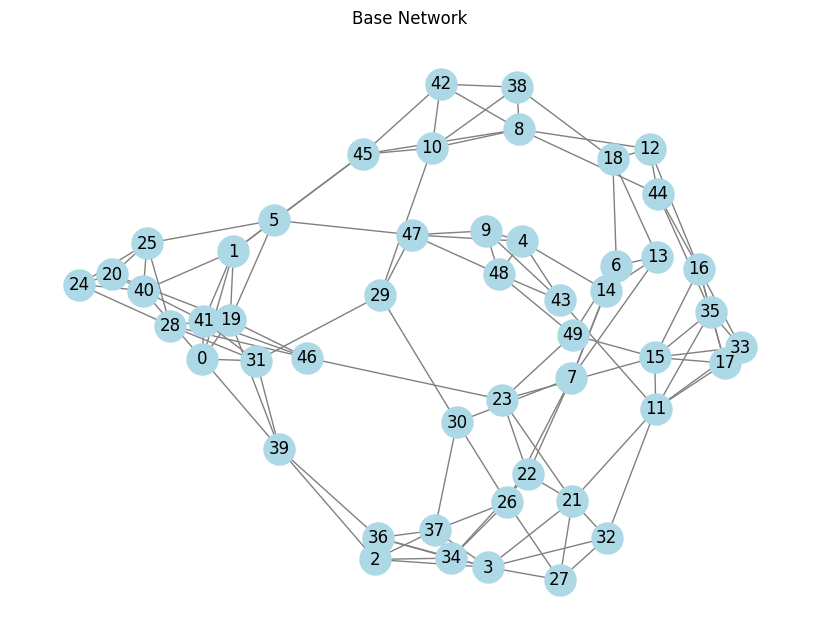

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# グラフ構築
G = nx.Graph()
G.add_edges_from(edges)

# 可視化（例: springレイアウト）
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)
plt.title("Base Network")
plt.show()
